<a href="https://colab.research.google.com/github/edwardmoreno18/redesNeuronales2/blob/main/04_Frutas_Multiclase_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales II - Laboratorio D

## Clasificación multiclase de frutas con TensorFlow + Keras

**Objetivo:** clasificar tres clases: manzana, banano y naranja, utilizando ReLU en la capa oculta y Softmax en la salida.

In [7]:

# ============================================
# 1. LIBRERÍAS
# ============================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [8]:

# ============================================
# LABORATORIO D - CLASIFICACIÓN MULTICLASE
# ============================================
# Clases:
# 0 = manzana
# 1 = banano
# 2 = naranja
#
# Ahora el modelo debe escoger una de tres categorías.

X_multi = np.array([
    # MANZANAS - 0
    [150,7.5,.10],[160,8.0,.15],[145,7.2,.05],[170,8.3,.20],[155,7.8,.10],
    [165,8.1,.15],[140,7.0,.05],[175,8.5,.20],[158,7.9,.10],[162,8.2,.15],

    # BANANOS - 1
    [120,18.0,.90],[125,19.0,.95],[115,17.5,.85],[130,20.0,1.00],[118,18.5,.90],
    [123,19.5,.95],[110,17.0,.80],[128,20.5,1.00],[121,18.8,.90],[126,19.2,.95],

    # NARANJAS - 2
    [180,8.0,.35],[190,8.5,.40],[175,7.8,.30],[200,9.0,.45],[185,8.2,.35],
    [195,8.7,.40],[170,7.5,.30],[205,9.2,.45],[188,8.4,.35],[192,8.6,.40]
], dtype=float)

y_multi = np.array([0]*10 + [1]*10 + [2]*10)

In [9]:
# ============================================
# SEPARAR Y ESCALAR
# ============================================
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

scaler_multi = StandardScaler()
X_train_multi = scaler_multi.fit_transform(X_train_multi)
X_test_multi = scaler_multi.transform(X_test_multi)

print("X_train_multi:", X_train_multi.shape)
print("X_test_multi :", X_test_multi.shape)

X_train_multi: (24, 3)
X_test_multi : (6, 3)


In [10]:
# ============================================
# CREAR RED MULTICLASE CON SOFTMAX
# ============================================
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)

modelo_multi = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(6, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

modelo_multi.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_multi.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45 (180.00 B)

 Trainable params: 45 (180.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================
# ENTRENAMIENTO
# ============================================
historial_multi = modelo_multi.fit(
    X_train_multi,
    y_train_multi,
    epochs=300,
    verbose=0
)



In [12]:
# ============================================
# EVALUACIÓN
# ============================================
loss_multi, accuracy_multi = modelo_multi.evaluate(
    X_test_multi,
    y_test_multi,
    verbose=0
)

print("Loss en prueba:", loss_multi)
print("Accuracy en prueba:", accuracy_multi)



Loss en prueba: 0.021294867619872093
Accuracy en prueba: 1.0


In [13]:
# ============================================
# PREDICCIONES
# ============================================
probabilidades_multi = modelo_multi.predict(
    X_test_multi,
    verbose=0
)

predicciones_multi = np.argmax(
    probabilidades_multi,
    axis=1
)

nombres_frutas = ["MANZANA", "BANANO", "NARANJA"]

print("\nPredicciones:", predicciones_multi)
print("Reales      :", y_test_multi)


Predicciones: [2 1 2 0 1 0]
Reales      : [2 1 2 0 1 0]


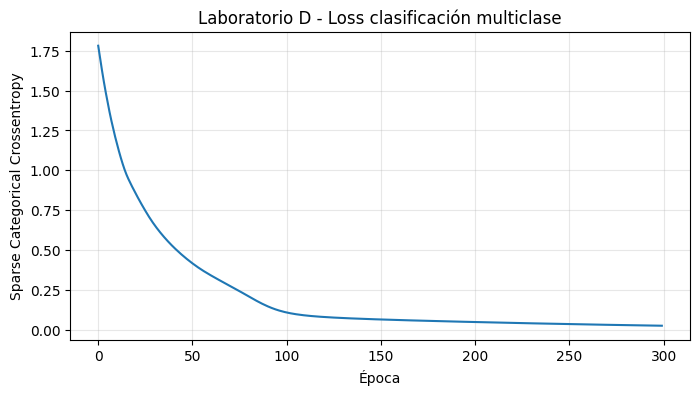

In [14]:
# ============================================
# GRAFICAR LOSS
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(historial_multi.history["loss"])
plt.title("Laboratorio D - Loss clasificación multiclase")
plt.xlabel("Época")
plt.ylabel("Sparse Categorical Crossentropy")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# ============================================
# PROBAR UNA NARANJA NUEVA
# ============================================
fruta_nueva_multi = np.array([[190, 8.5, 0.38]])
fruta_nueva_multi = scaler_multi.transform(fruta_nueva_multi)

prob = modelo_multi.predict(fruta_nueva_multi, verbose=0)
clase = np.argmax(prob, axis=1)[0]

print("\nProbabilidades:", prob[0])
print("Clasificación:", nombres_frutas[clase])


Probabilidades: [5.3335901e-04 4.3026306e-04 9.9903643e-01]
Clasificación: NARANJA


### Punto clave
En clasificación multiclase la capa final tiene 3 neuronas. `softmax` produce una distribución de probabilidades y `argmax` selecciona la clase con mayor valor.